In [1]:
# importamos respectivas librerias a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# cargamos los datsasets
df_companys = pd.read_csv('./moved_project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('./moved_project_sql_result_04.csv')

mostramos la informacion de cada dataset

In [3]:
df_companys.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [4]:
df_neighborhoods.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [5]:
df_companys.head()


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [6]:
df_neighborhoods.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


Se observa que en estos dos dataframes no hay valores nulos y que los tipos de datos estan bien.

In [7]:
# identificamos los 10 principales barrios en terminos de finalizacion del recorrido
top_neighborhoods = df_neighborhoods.sort_values(by='average_trips', ascending = False).head(10)
print(top_neighborhoods)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


Graficamos

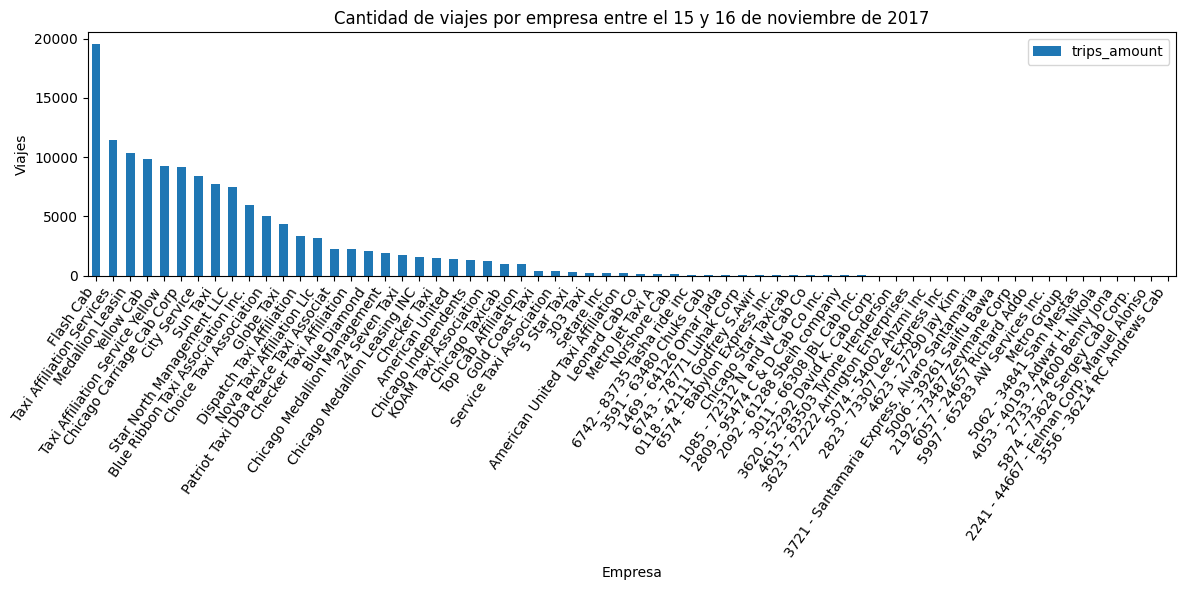

In [8]:
df_companys.plot(
    x = 'company_name',
    y = 'trips_amount',
    kind = 'bar',
    figsize = (12,6),
    title = 'Cantidad de viajes por empresa entre el 15 y 16 de noviembre de 2017',
    xlabel = 'Empresa',
    ylabel = 'Viajes'
)
plt.xticks(rotation=55, ha='right') # rotamos los nombres 55 grados a la derecha
plt.tight_layout()  # ajusta espaciado automaticamente
plt.show()

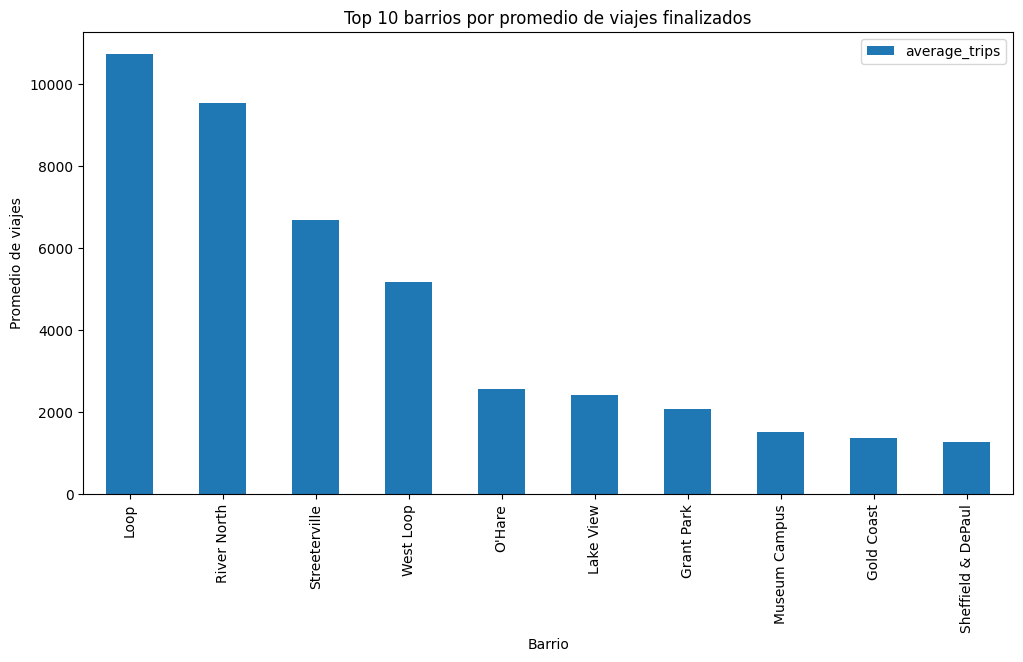

In [9]:
top_neighborhoods.plot(
    x = 'dropoff_location_name',
    y = 'average_trips',
    kind = 'bar',
    figsize = (12,6),
    title = 'Top 10 barrios por promedio de viajes finalizados',
    xlabel = 'Barrio',
    ylabel = 'Promedio de viajes'
)
plt.show()

# Conclusiones.

respecto al primer grafico se puede deducir que entre el 15 y 16 de noviembre de 2017, más de la mitad de las empresas no superan los 1,000 viajes, la empresa Flash Cab resalta notablemente llegando casi a los 20,000 viajes.

en cuanto al segundo grafico, el barrio con mejor promedio de viajes finalizados es Loop que supera los 10000, desde O'hare en adelante no superaron los 3,000 de promedio de viajes finalizados.

# Prueba de hipotesis.

In [10]:
# cargamos dataset de la ultima consulta
df_consulta_viajes = pd.read_csv('./moved_project_sql_result_07.csv')

In [11]:
# mostramos los primeros 10 viajes.
df_consulta_viajes.head(10)

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0
5,2017-11-11 04:00:00,Good,1320.0
6,2017-11-04 16:00:00,Bad,2969.0
7,2017-11-18 11:00:00,Good,2280.0
8,2017-11-11 14:00:00,Good,2460.0
9,2017-11-11 12:00:00,Good,2040.0


In [12]:
# agrupamos
sabados_buen_clima = df_consulta_viajes[df_consulta_viajes['weather_conditions'] == 'Good']['duration_seconds']
sabados_mal_clima = df_consulta_viajes[df_consulta_viajes['weather_conditions'] == 'Bad']['duration_seconds']
# mostramos informacion promedio de cada grupo
print(f'duracion promedio buen clima: {sabados_buen_clima.mean():.2f} segundos')
print(f'duracion promedio mal clima: {sabados_mal_clima.mean():.2f} segundos')

duracion promedio buen clima: 1999.68 segundos
duracion promedio mal clima: 2427.21 segundos


# Hipotesis nula (H0).
la duracion promedio de viajes tanto en sabados con buen clima como en sabados con mal clima es igual.

# Hipotesis alternativa (H1).
la duracion promedio de viajes los sabados con buen clima es diferente a la duracion promedio de viajes los sabados con mal clima.

In [13]:
# realizamos prueba de hipotesis normal.
# importamos libreria 
from scipy import stats as st

# Realizar la prueba t para muestras independientes
resultado = st.ttest_ind(sabados_mal_clima, sabados_buen_clima)

print(f"Estadístico t: {resultado.statistic:.4f}")
print(f"Valor p: {resultado.pvalue:.6f}")
# escogemos el nivel de significacion alfa 0.05 el mas comun 
print(f"Nivel de significación (α): 0.05")
print("-" * 40)

# Interpretación automática
if resultado.pvalue < 0.05:
    print("RESULTADO: Rechazamos H₀")
    print("La diferencia en duración ES estadísticamente significativa")
else:
    print("RESULTADO: No rechazamos H₀") 
    print("No hay evidencia suficiente de diferencia significativa")

Estadístico t: 6.9462
Valor p: 0.000000
Nivel de significación (α): 0.05
----------------------------------------
RESULTADO: Rechazamos H₀
La diferencia en duración ES estadísticamente significativa


# CONCLUSION.

la duracion promedio de viajes desde Loop hasta el aeropuerto internacional O'hare SI cambia los sabados lluviosos, se planteo la hipotesis nula de que la duracion promedio de los viajes para los sabados con buen y mal clima eran iguales, y una hipotesis alternativa de que sí habia diferencia en el promedio de duracion, se establecio un nivel de sifnificancia alfa de 0.05 el mas comun y se realizo prueba t para muestras independientes la cual nos mostro:

Estadístico t: 6.9462 Valor p: 0.000000 Nivel de significación (α): 0.05

Se rechaza la hipotesis nula ya que la duracion es estadisticamente significativa, puede deberse a que cuando hace mal clima, usualmente hay mas trancon, los carros manejan mas lento, hay mas accidentes.